<a href="https://colab.research.google.com/github/Lucaaa31/Anomaly-Segmentation/blob/master/notebooks/Step5_FineTuning_EomtCoco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 5 - Fine-tune EoMT-COCO on Cityscapes (configurable strategy)

Fine-tuning pipeline. Starts from `models/eomt_coco.bin` (panoptic, 133 classes) and re-targets it to Cityscapes 19-class semantic segmentation.

A single `STRATEGY` variable at the top selects what gets trained:

* **`head_only_lora`** - freeze the DINOv2 backbone, train only the prediction head (`q`, `class_head`, `mask_head`, `upscale`) plus **LoRA** adapters on the encoder attention (`qkv`, `proj`). Fast, small trainable budget, parameter-efficient (PEFT) baseline.
* **`full`** - train every parameter, with a **discriminative LR** (head ~1e-4, backbone ~1e-5). Slower, much larger trainable budget, expected to give the best mIoU.
* **`phased`** - progressive unfreezing in **5 phases** over the run: P1 = head only (pure, no LoRA), P2 = head + last 3 encoder blocks (the EoMT mask-attention blocks), P3 = head + last 6, P4 = head + last 9, P5 = full network. Discriminative LR (head 10x backbone). The phase is recomputed from the current optimizer step after every step, so the run rebalances itself automatically — no need to start a new training session per phase. **At every phase boundary** a full Cityscapes val evaluation (both `strict` and `common` label spaces, all 500 imgs) is run, the per-phase weights are saved as `ckpt_phase{N}.pt`, and a row is appended to `results/step5_phased_per_phase.txt` so the gradual-unfreezing curve is preserved.

Output is split across two folders, one strategy-specific subfolder each:

* **Intermediate checkpoints** -> `checkpoints/{STRATEGY}/`
  * `ckpt_latest.pt` - full training state for resumption (model + optimizer + scheduler + scaler + step + best_miou).
  * `ckpt_best.pt`   - same shape, frozen at the highest val mIoU seen during training.
  * (`phased` only) `ckpt_phase{1..5}.pt` - model weights snapshotted at the end of each phase, used to reconstruct the gradual-unfreezing mIoU curve.
* **Final model weights** -> `models/coco_finetune/{STRATEGY}/`
  * `eomt_finetuned_{STRATEGY}.bin` - **model-only weights** (no optimizer state), ready to be loaded by Steps 6-8 in the same way as the provided `eomt_*.bin`.

After the full final evaluation, a per-strategy block is appended to `results/step5_results.txt` (with both **strict** and **common** mIoU, same convention as Step 4) so you can re-run the notebook with a different `STRATEGY` and accumulate results.

**Live tracking on Weights & Biases.** All training metrics (loss, LR, val-mIoU, phase transitions) stream to wandb under a project-level run named `eomt-coco-{STRATEGY}`. Resumed Colab sessions reattach to the same run so the plots stay continuous across machines. Toggle with `USE_WANDB` in the config cell.

**Multi-machine resilience.** Every `CKPT_EVERY_STEPS` we save a full checkpoint to Drive. On startup we resume from the strategy's `ckpt_latest.pt` automatically. For `phased`, the correct phase is re-derived from the resumed `global_step` so a session continuing across phase boundaries does the right thing.

Helpers are imported from [utils/eval_semantic.py](../utils/eval_semantic.py) and the EoMT subtree at [models/eomt/](../models/eomt/).

## 1. Mount Drive and pull latest code

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Colab_Projects/Anomaly-Segmentation
#!git pull origin master

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab_Projects/Anomaly-Segmentation


## 2. Install dependencies

In [ ]:
!pip install -q -r requirements.txt
import torch, lightning, timm, transformers, scipy, fvcore, pycocotools, numpy as np
print(f'torch={torch.__version__}  cuda={torch.cuda.is_available()}  numpy={np.__version__}  '
      f'lightning={lightning.__version__}  timm={timm.__version__}')

torch=2.10.0+cu128  cuda=True  numpy=1.26.4  lightning=2.6.4  timm=1.0.26


## 3. Imports and paths

Both the project root (for `utils.eval_semantic`) and `eomt/` (for the YAML class_path strings) must be on `sys.path`.

In [ ]:
import math, time, sys
from pathlib import Path

import torch
import torch.nn as nn
from torch.amp import autocast, GradScaler
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

REPO_ROOT = Path('/content/drive/MyDrive/Colab_Projects/Anomaly-Segmentation')
EOMT_DIR  = REPO_ROOT / 'models' / 'eomt'
DATA_PATH = REPO_ROOT / 'dataset' / 'Cityscapes'
# CKPT_DIR is built per-strategy in the next cell (depends on STRATEGY).

# Repo root must be on sys.path so `utils.X` modules resolve; models/eomt/ must
# be on sys.path so the YAML class_path entries (datasets.*, training.*, models.*) resolve.
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(EOMT_DIR))

# Helpers from the project subpackage. utils/ is split by concern:
#   utils.build         -> build_model_and_data
#   utils.eval_semantic -> evaluate_semantic, print_iou_table, CS_CLASS_NAMES (mIoU only)
from utils.build import build_model_and_data
from utils.eval_semantic import evaluate_semantic, print_iou_table, CS_CLASS_NAMES

assert torch.cuda.is_available(), 'Enable GPU runtime: Runtime - Change runtime type - T4 GPU'
device = torch.device('cuda')
print('device:', device, '| torch:', torch.__version__, '| GPU:', torch.cuda.get_device_name(0))

device: cuda | torch: 2.10.0+cu128 | GPU: NVIDIA L4


## 4. Configuration (strategy switcher + hyperparameters)

`STRATEGY` selects which fine-tuning recipe to run. Everything that differs between recipes (LR, total optimizer steps, freeze policy, LoRA on/off) lives in `STRATEGY_CONFIGS`. Checkpoints land in a strategy-specific folder so different runs don't overwrite each other.

The loop saves a checkpoint every `CKPT_EVERY_STEPS` and stops cleanly before the time budget elapses, so the next teammate starting the notebook resumes from the latest checkpoint **of the same strategy**.

In [ ]:
# --- Strategy switcher ------------------------------------------------------
STRATEGY = "full"   # "head_only_lora" / "phased" / "full"
assert STRATEGY in ("head_only_lora", "full", "phased"), f"unknown STRATEGY: {STRATEGY}"

# Per-strategy hyperparameters.
#   head_only_lora -> backbone frozen, head + LoRA trained, smaller budget.
#   full           -> all params trained with discriminative LR (head 10x backbone),
#                     LoRA disabled (would be redundant when the backbone is unfrozen),
#                     larger budget because the optimization landscape is wider.
#   phased         -> 5-phase progressive unfreezing of the encoder backbone.
#                     P1: head only (last_n=0) -> P2: +last 3 blocks (the EoMT
#                     mask-attention blocks) -> P3: +last 6 -> P4: +last 9 ->
#                     P5: all 12 blocks. Discriminative LR (head 10x backbone).
#                     LoRA off (the backbone gets unfrozen anyway, so LoRA would
#                     be redundant). PHASE_FRACTIONS sums to 1.
STRATEGY_CONFIGS = {
    "head_only_lora": {
        "use_lora":     True,
        "lr_head":      1e-4,
        "lr_backbone":  0.0,    # backbone frozen
        "lr_lora":      1e-4,
        "total_steps":  12000,
        "warmup_steps": 500,
    },
    "full": {
        "use_lora":     False,
        "lr_head":      1e-4,
        "lr_backbone":  1e-5,   # 10x smaller than the head
        "lr_lora":      0.0,
        "total_steps":  20000,
        "warmup_steps": 1000,
    },
    "phased": {
        "use_lora":              False,
        "lr_head":               1e-4,
        "lr_backbone":           1e-5,    # 10x smaller than the head
        "lr_lora":               0.0,
        "total_steps":           20000,
        "warmup_steps":          750,
        # 5-phase progressive unfreezing.
        #   index:           0    1    2    3    4    (== phase number - 1)
        #   phase:           P1   P2   P3   P4   P5
        #   trainable head:  yes  yes  yes  yes  yes
        #   last_n blocks:   0    3    6    9    12
        "phase_fractions":       (0.15, 0.15, 0.20, 0.20, 0.30),  # sums to 1
        "phase_unfreeze_last_n": (0,    3,    6,    9,    12),
    },
}
cfg = STRATEGY_CONFIGS[STRATEGY]
USE_LORA              = cfg["use_lora"]
LR_HEAD               = cfg["lr_head"]
LR_BACKBONE           = cfg["lr_backbone"]
LR_LORA               = cfg["lr_lora"]
TOTAL_STEPS           = cfg["total_steps"]
WARMUP_STEPS          = cfg["warmup_steps"]
PHASE_FRACTIONS       = cfg.get("phase_fractions")        # phased only
PHASE_UNFREEZE_LAST_N = cfg.get("phase_unfreeze_last_n")  # phased only
print(f'[config] STRATEGY={STRATEGY}  total_steps={TOTAL_STEPS}  '
      f'lr_head={LR_HEAD}  lr_backbone={LR_BACKBONE}  use_lora={USE_LORA}')
if STRATEGY == "phased":
    print(f'[config] phase_fractions={PHASE_FRACTIONS}')
    print(f'[config] phase_unfreeze_last_n={PHASE_UNFREEZE_LAST_N}')

# --- Per-strategy output folders --------------------------------------------
# Intermediate checkpoints (latest + best, full training state) live under
# `checkpoints/`; the final model-only .bin lives under `models/coco_finetune/`.
# Both directories use a strategy-specific subfolder so different runs do not
# overwrite each other.
CKPT_DIR  = REPO_ROOT / 'checkpoints' / STRATEGY
FINAL_DIR = REPO_ROOT / 'models' / 'coco_finetune' / STRATEGY
CKPT_DIR.mkdir(parents=True, exist_ok=True)
FINAL_DIR.mkdir(parents=True, exist_ok=True)
print(f'[config] CKPT_DIR  = {CKPT_DIR}')
print(f'[config] FINAL_DIR = {FINAL_DIR}')

# --- Source weights / config (shared across strategies) ---------------------
import shutil
LOCAL_COCO = Path('/content/eomt_coco.bin')
DRIVE_COCO = REPO_ROOT / 'models' / "eomt_eval" / 'eomt_coco.bin'

if LOCAL_COCO.exists():
    print(f'COCO ckpt already in local: {LOCAL_COCO}')
    COCO_CKPT = LOCAL_COCO
else:
    print(f'Copying COCO ckpt from Drive to {LOCAL_COCO}')
    shutil.copy(DRIVE_COCO, LOCAL_COCO)
    print('Done')
    COCO_CKPT = LOCAL_COCO
CS_CONFIG = REPO_ROOT / 'configs' / 'dinov2' / 'cityscapes' / 'semantic' / 'eomt_base_640.yaml'

# --- Common training hyperparameters ----------------------------------------
IMG_SIZE         = (640, 640)   # smaller than upstream (1024,1024) to fit Colab T4 memory
BATCH_SIZE       = 2            # per-step batch on T4
GRAD_ACCUM       = 8            # effective batch = BATCH_SIZE * GRAD_ACCUM = 16 (matches upstream)
NUM_WORKERS      = 2
WEIGHT_DECAY     = 0.1          # bumped from 0.05 to add stronger regularization
LOG_EVERY_STEPS  = 25
CKPT_EVERY_STEPS = 200
VAL_EVERY_STEPS  = 250          # frequent val so early stopping has fine-grained signal
VAL_MAX_IMAGES   = 100          # cap intermediate val to keep iterations short (-1 = full 500)

# Early stopping on val mIoU. PATIENCE = number of consecutive validations
# without a strict improvement of at least MIN_DELTA before the run is killed.
# With VAL_EVERY_STEPS=250 and PATIENCE=8, training stops after ~2000 optimizer
# steps of plateau — useful for `head_only_lora`, where the trainable budget is
# tiny and the model usually plateaus well before TOTAL_STEPS. For `phased`
# early stopping is disabled (set patience high) because intermediate phases
# legitimately plateau before the next unfreezing — we don't want to kill a
# phased run mid-schedule.
EARLY_STOP_PATIENCE  = 12 if STRATEGY != "phased" else 10_000
EARLY_STOP_MIN_DELTA = 1e-4

# LoRA hyperparameters (only used when USE_LORA=True)
LORA_R     = 8
LORA_ALPHA = 16

# Weights & Biases logging. Set USE_WANDB=False to skip wandb completely.
# Run ID is stable per strategy so resumed Colab sessions append to the same
# wandb run instead of creating a new one each time.
USE_WANDB     = True
WANDB_PROJECT = "anomaly-segmentation"
WANDB_RUN_ID  = f"eomt-coco-{STRATEGY}_v2"

# Colab time budget per session (leaves headroom before colab kills the runtime)
TIME_BUDGET_SEC   = int(17.3 * 3600)
SAFETY_MARGIN_SEC = 5 * 60

def fmt(sec):
    h, rem = divmod(sec, 3600); m, s = divmod(rem, 60)
    return f"{h}h {m}m {s}s"

print(f"Maximum time of run: {fmt(TIME_BUDGET_SEC)}")
print(f"Safety margin:       {fmt(SAFETY_MARGIN_SEC)}")
print(f"Effective budget:    {fmt(TIME_BUDGET_SEC - SAFETY_MARGIN_SEC)}")

torch.manual_seed(0)

[config] STRATEGY=full  total_steps=20000  lr_head=0.0001  lr_backbone=1e-05  use_lora=False
[config] CKPT_DIR  = /content/drive/MyDrive/Colab_Projects/Anomaly-Segmentation/checkpoints/full
[config] FINAL_DIR = /content/drive/MyDrive/Colab_Projects/Anomaly-Segmentation/models/coco_finetune/full
COCO ckpt already in local: /content/eomt_coco.bin
Maximum time of run: 17h 18m 0s
Safety margin:       0h 5m 0s
Effective budget:    17h 13m 0s


## 5. Build the model from the COCO checkpoint

We use the **Cityscapes** YAML config - so the lightning module is shaped for 19 classes - but load weights from `eomt_coco.bin` with `skip_class_head=True`. Encoder, mask head, queries and upscale all come from COCO; the class head is randomly initialized for the new 19-class space.

We override `img_size` so the model is built for 640x640 training crops.

In [ ]:
data_overrides = {
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'num_workers': NUM_WORKERS,
}
model, data = build_model_and_data(
    CS_CONFIG, COCO_CKPT, DATA_PATH, device,
    setup_data=True, skip_class_head=True, data_overrides=data_overrides,
)
data.setup()
print(f'num_classes={model.num_classes}  img_size={model.img_size}')
print(f'class_head shape: {tuple(model.network.class_head.weight.shape)}  '
      f'(expected ({model.num_classes + 1}, embed_dim))')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.


  [info] skip_class_head: dropped 2 class-head key(s)
  [info] skip_class_head: dropped 2 shape-mismatched key(s):
    network.q.weight: ckpt (200, 768) vs model (100, 768)
    criterion.empty_weight: ckpt (134,) vs model (20,)
  [warn] missing keys: 4
num_classes=19  img_size=(640, 640)
class_head shape: (20, 768)  (expected (20, embed_dim))


## 6. Freeze policy (driven by `STRATEGY`)

* `head_only_lora` - freeze everything, then unfreeze the prediction head: `q`, `class_head`, `mask_head`, `upscale`. The encoder backbone is left frozen and any extra capacity comes from the LoRA adapters added in the next cell.
* `full` - leave all parameters trainable (every `requires_grad = True`).
* `phased` - **5-phase** progressive unfreezing of the encoder. At phase `i` (0-indexed: 0..4 corresponding to P1..P5), the head is always trainable plus the last `PHASE_UNFREEZE_LAST_N[i]` encoder backbone blocks. The schedule is `(0, 3, 6, 9, 12)`, i.e. P1=head only, P2=+3, P3=+6, P4=+9, P5=full. The phase is recomputed from `global_step` after each optimizer step; the optimizer is built once over **all** parameters (see next cells), so flipping `requires_grad` is enough — `AdamW` skips parameters whose gradient is `None` and lazily initializes momentum state when they are first updated.

Defines the helpers `apply_phase` and `phase_for_step` used by the training loop, plus a small `count_params` for trainable-budget logging.

In [ ]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

# --- phased helpers (no-ops when STRATEGY != "phased") ----------------------
def apply_phase(model, phase: int):
    """Set `requires_grad` on the network based on the current 5-phase index.

    phase ∈ {0,1,2,3,4} (corresponding to P1..P5). The head (q, class_head,
    mask_head, upscale) is always trainable; the last `PHASE_UNFREEZE_LAST_N[phase]`
    encoder backbone blocks are also trainable (0 in P1, 12 = all in P5).
    """
    last_n = PHASE_UNFREEZE_LAST_N[phase]
    for p in model.parameters():
        p.requires_grad = False
    for module_name in ('q', 'class_head', 'mask_head', 'upscale'):
        for p in getattr(model.network, module_name).parameters():
            p.requires_grad = True
    if last_n > 0:
        blocks = list(model.network.encoder.backbone.blocks)
        for blk in blocks[-last_n:]:
            for p in blk.parameters():
                p.requires_grad = True


def phase_for_step(step: int) -> int:
    """Map a global optimizer step to a 0-indexed phase using cumulative PHASE_FRACTIONS."""
    cumulative = 0.0
    for i, frac in enumerate(PHASE_FRACTIONS):
        cumulative += frac
        if step < int(round(TOTAL_STEPS * cumulative)):
            return i
    return len(PHASE_FRACTIONS) - 1  # clamp to last phase

# --- Apply the strategy's initial freeze policy -----------------------------
if STRATEGY == "head_only_lora":
    for p in model.parameters():
        p.requires_grad = False
    for module_name in ['q', 'class_head', 'mask_head', 'upscale']:
        for p in getattr(model.network, module_name).parameters():
            p.requires_grad = True
elif STRATEGY == "full":
    for p in model.parameters():
        p.requires_grad = True
elif STRATEGY == "phased":
    apply_phase(model, phase=0)
    cum = 0.0
    boundaries = []
    for frac in PHASE_FRACTIONS:
        cum += frac
        boundaries.append(int(round(TOTAL_STEPS * cum)))
    print(f'[phased] phase end boundaries (step): {boundaries}  '
          f'(of {TOTAL_STEPS}); unfreeze_last_n schedule: {PHASE_UNFREEZE_LAST_N}')

total, trainable = count_params(model)
print(f'[{STRATEGY}] trainable: {trainable/1e6:.2f}M / {total/1e6:.2f}M  ({100*trainable/total:.2f}%)')

[full] trainable: 93.50M / 93.50M  (100.00%)


## 7. LoRA on encoder attention (qkv, proj)

Tiny LoRA wrapper: replaces each `nn.Linear` named `qkv` or `proj` inside the encoder backbone blocks with `base_linear(x) + (x A^T) B^T * scale`. Base weights stay frozen; only `A` and `B` are trained. This adds a small trainable budget on top of the prediction head.

In [ ]:
class LoRALinear(nn.Module):
    def __init__(self, base: nn.Linear, r: int, alpha: int):
        super().__init__()
        self.base = base
        for p in self.base.parameters():
            p.requires_grad = False
        self.A = nn.Parameter(torch.zeros(r, base.in_features))
        self.B = nn.Parameter(torch.zeros(base.out_features, r))
        nn.init.kaiming_uniform_(self.A, a=5 ** 0.5)
        self.scale = alpha / r

    def forward(self, x):
        return self.base(x) + (x @ self.A.T @ self.B.T) * self.scale


def add_lora(root: nn.Module, target_names=('qkv', 'proj'), r=8, alpha=16):
    n_added = 0
    for parent in root.modules():
        for child_name, child in list(parent.named_children()):
            if isinstance(child, nn.Linear) and child_name in target_names:
                setattr(parent, child_name, LoRALinear(child, r=r, alpha=alpha))
                n_added += 1
    return n_added

if USE_LORA:
    n = add_lora(model.network.encoder.backbone.blocks, r=LORA_R, alpha=LORA_ALPHA)
    model.to(device)
    total, trainable = count_params(model)
    print(f'LoRA wrapped {n} linears | trainable now: {trainable/1e6:.2f}M  ({100*trainable/total:.2f}%)')
else:
    print('LoRA disabled')

LoRA disabled


## 8. Train and val dataloaders

Both come from the same `CityscapesSemantic` data module that `build_model_and_data` already set up - no need to re-instantiate. Training uses the upstream augmentations (color jitter, scale jitter, random crop) defined in `eomt/datasets/transforms.py`.

In [ ]:
from torch.utils.data import Subset
import numpy as np
from collections import defaultdict

train_loader = data.train_dataloader()
val_loader   = data.val_dataloader()
val_dataset  = val_loader.dataset
print(f'train: {len(train_loader.dataset)} images | val: {len(val_dataset)} images')
print(f'optimizer steps per epoch: {len(train_loader) // GRAD_ACCUM}')

# --- Build a city-stratified val subset for quick_val -----------------------
# The full Cityscapes val (500 imgs) is interleaved by city in dataset order
# (Frankfurt / Lindau / Munster), so taking the first VAL_MAX_IMAGES would be
# heavily biased toward Frankfurt. We sample VAL_MAX_IMAGES evenly across the
# three cities so the per-step val mIoU (used for early stopping and
# best-checkpoint selection) reflects all three and the absolute number is
# closer to the full-val number printed in the final eval cell.
city_indices = defaultdict(list)
for idx, img_path in enumerate(val_dataset.imgs):
    city = Path(img_path).parent.name  # 'frankfurt' / 'lindau' / 'munster'
    city_indices[city].append(idx)

cities_sorted = sorted(city_indices.keys(), key=lambda c: len(city_indices[c]), reverse=True)
per_city = VAL_MAX_IMAGES // len(cities_sorted)
extras   = VAL_MAX_IMAGES - per_city * len(cities_sorted)

stratified_indices = []
per_city_picked = {}
for i, city in enumerate(cities_sorted):
    n = per_city + (1 if i < extras else 0)  # spread leftover slots over the largest cities
    pool = city_indices[city]
    pick = [pool[int(round(j))] for j in np.linspace(0, len(pool) - 1, n)]
    stratified_indices.extend(pick)
    per_city_picked[city] = len(pick)

stratified_indices = sorted(set(stratified_indices))
VAL_SUBSET = Subset(val_dataset, stratified_indices)
counts_str = ", ".join(f"{c}={per_city_picked[c]}" for c in cities_sorted)
print(f'stratified val subset: {len(VAL_SUBSET)} imgs ({counts_str})')

train: 2975 images | val: 500 images
optimizer steps per epoch: 185
stratified val subset: 100 imgs (frankfurt=34, munster=33, lindau=33)


## 9. Optimizer, scheduler, AMP scaler

Three potential parameter groups (head, backbone, LoRA) so each gets its own LR. Empty groups (e.g. backbone under `head_only`, LoRA under `full`) are skipped automatically. Linear warmup + cosine decay over `TOTAL_STEPS`.

For **`phased`** the optimizer is built over **all** parameters (including currently-frozen backbone params), so flipping `requires_grad` at phase boundaries is enough — `AdamW` skips parameters with `grad=None` and lazily initializes momentum state when they first receive a gradient. The cosine schedule is global (not per-phase), which means backbone parameters start being updated once the LR is already in its decay region — desirable for a pretrained backbone.

In [ ]:
# For "phased" the optimizer must include backbone params even though they
# start frozen — AdamW will skip them while their grad is None and pick them
# up automatically once apply_phase() flips requires_grad on.
include_all = (STRATEGY == "phased")

head_params, lora_params, backbone_params = [], [], []
for n_, p in model.named_parameters():
    if not include_all and not p.requires_grad:
        continue
    if n_.endswith('.A') or n_.endswith('.B'):
        lora_params.append(p)
    elif 'encoder.backbone' in n_:
        backbone_params.append(p)
    else:
        head_params.append(p)

param_groups = []
if head_params:
    param_groups.append({'params': head_params, 'lr': LR_HEAD, 'name': 'head'})
if backbone_params:
    param_groups.append({'params': backbone_params, 'lr': LR_BACKBONE, 'name': 'backbone'})
if lora_params:
    param_groups.append({'params': lora_params, 'lr': LR_LORA, 'name': 'lora'})

optimizer = AdamW(param_groups, weight_decay=WEIGHT_DECAY)

def lr_lambda(step):
    if step < WARMUP_STEPS:
        return step / max(1, WARMUP_STEPS)
    progress = (step - WARMUP_STEPS) / max(1, TOTAL_STEPS - WARMUP_STEPS)
    return 0.5 * (1.0 + math.cos(math.pi * min(1.0, progress)))

scheduler = LambdaLR(optimizer, lr_lambda)
scaler    = GradScaler('cuda')
criterion = model.criterion
print(f'param groups: {[(g["name"], len(g["params"]), g["lr"]) for g in param_groups]}')

param groups: [('head', 19, 0.0), ('backbone', 175, 0.0)]


## 10. Checkpoint helpers (Drive)

A checkpoint is everything needed to resume identically on another machine: model state, optimizer, scheduler, AMP scaler, `global_step`, and the best mIoU we have seen so far. We keep `ckpt_latest.pt` (rotating) and `ckpt_best.pt` (highest val mIoU).

In [ ]:
LATEST_CKPT = CKPT_DIR / 'ckpt_latest.pt'
BEST_CKPT   = CKPT_DIR / 'ckpt_best.pt'

def save_ckpt(path, model, optimizer, scheduler, scaler, *, global_step, best_miou,
              train_loss_history=None, val_miou_history=None):
    tmp = path.with_suffix('.pt.tmp')
    torch.save({
        'model':     model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'scaler':    scaler.state_dict(),
        'global_step': global_step,
        'best_miou':   best_miou,
        # Persist (step, value) histories so the final plot survives resume.
        'train_loss_history': list(train_loss_history or []),
        'val_miou_history':   list(val_miou_history or []),
    }, tmp)
    # Google Drive FUSE doesn't reliably overwrite via Path.replace —
    # it can leave the old file in place and create a new object with the
    # same name, leading to duplicate ckpt_latest.pt files (and quota waste).
    # Cancel any existing same-name file(s) explicitly, then rename.
    for stale in path.parent.glob(path.name):
        try:
            stale.unlink()
        except FileNotFoundError:
            pass
    tmp.rename(path)


def load_ckpt(path, model, optimizer, scheduler, scaler, device):
    if not path.exists():
        return {'global_step': 0, 'best_miou': -1.0, 'resumed': False,
                'train_loss_history': [], 'val_miou_history': []}
    print(f'resuming from {path}')
    ck = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ck['model'])
    optimizer.load_state_dict(ck['optimizer'])
    scheduler.load_state_dict(ck['scheduler'])
    scaler.load_state_dict(ck['scaler'])
    return {
        'global_step': ck['global_step'],
        'best_miou':   ck['best_miou'],
        # `.get` so older checkpoints (saved before histories were tracked) still load.
        'train_loss_history': ck.get('train_loss_history', []),
        'val_miou_history':   ck.get('val_miou_history',   []),
        'resumed': True,
    }

## 11. Resume from latest (if any)

In [ ]:
state = load_ckpt(LATEST_CKPT, model, optimizer, scheduler, scaler, device)
global_step        = state['global_step']
best_miou          = state['best_miou']
train_loss_history = state['train_loss_history']  # list of (step, loss)
val_miou_history   = state['val_miou_history']    # list of (step, mIoU in [0,1])
print(f'starting from step {global_step}/{TOTAL_STEPS} | best mIoU so far: {best_miou*100:.2f} '
      f'| history: {len(train_loss_history)} loss pts, {len(val_miou_history)} val pts'
      if state['resumed'] else f'fresh run (no checkpoint at {LATEST_CKPT})')

# For phased, re-derive the correct phase from the resumed global_step so a
# session continuing across a phase boundary doesn't get stuck in P1.
if STRATEGY == "phased":
    current_phase = phase_for_step(global_step)
    apply_phase(model, current_phase)
    _t, _tr = count_params(model)
    print(f'[phased] resumed in phase P{current_phase + 1} '
          f'(last_n={PHASE_UNFREEZE_LAST_N[current_phase]}) | trainable: '
          f'{_tr/1e6:.2f}M / {_t/1e6:.2f}M ({100*_tr/_t:.2f}%)')
else:
    current_phase = None

fresh run (no checkpoint at /content/drive/MyDrive/Colab_Projects/Anomaly-Segmentation/checkpoints/full/ckpt_latest.pt)


## 11.5. Initialize Weights & Biases

Live loss / LR / val-mIoU dashboards on wandb. The run ID is fixed per `STRATEGY` (`eomt-coco-{STRATEGY}`) so resumed Colab sessions reattach to the same run and the plot stays continuous across machines. Set `USE_WANDB = False` in the config cell to skip entirely.

First-time setup: paste your API key from https://wandb.ai/authorize when prompted.

In [ ]:
if USE_WANDB:
    import wandb
    # `wandb.login()` uses the cached API key on Colab. First time: it prompts
    # for the key you copy from https://wandb.ai/authorize.
    try:
      from google.colab import userdata
      wandb.login(key=userdata.get('WANDB_API_KEY'))
    except Exception:
      wandb.login()

    wandb_run = wandb.init(
        project=WANDB_PROJECT,
        name=WANDB_RUN_ID,
        id=WANDB_RUN_ID,
        resume='allow',    # resumed Colab sessions append to the same wandb run
        config={
            'strategy':                STRATEGY,
            'total_steps':             TOTAL_STEPS,
            'warmup_steps':            WARMUP_STEPS,
            'lr_head':                 LR_HEAD,
            'lr_backbone':             LR_BACKBONE,
            'lr_lora':                 LR_LORA,
            'batch_size':              BATCH_SIZE,
            'grad_accum':              GRAD_ACCUM,
            'effective_batch':         BATCH_SIZE * GRAD_ACCUM,
            'weight_decay':            WEIGHT_DECAY,
            'img_size':                IMG_SIZE,
            'use_lora':                USE_LORA,
            'lora_r':                  LORA_R if USE_LORA else None,
            'lora_alpha':              LORA_ALPHA if USE_LORA else None,
            'phase_fractions':         PHASE_FRACTIONS,
            'phase_unfreeze_last_n':   PHASE_UNFREEZE_LAST_N,
            'early_stop_patience':     EARLY_STOP_PATIENCE,
            'early_stop_min_delta':    EARLY_STOP_MIN_DELTA,
        },
    )
    print(f'wandb run: {wandb_run.url}')
else:
    wandb_run = None
    print('wandb logging disabled (USE_WANDB=False)')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: simonepaoletti17 (simonepaoletti17-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb run: https://wandb.ai/simonepaoletti17-politecnico-di-torino/anomaly-segmentation/runs/eomt-coco-full_v2


## 12. Per-batch loss

EoMT outputs mask and class logits **per intermediate block**; the criterion is computed for each and weighted-summed (see [eomt/training/lightning_module.py](eomt/training/lightning_module.py)). We replicate the same weighting here so loss values match the upstream training_step.

In [ ]:
def compute_total_loss(mask_logits_per_block, class_logits_per_block, targets, criterion):
    total = None
    for ml, cl in zip(mask_logits_per_block, class_logits_per_block):
        d = criterion(masks_queries_logits=ml, class_queries_logits=cl, targets=targets)
        for k, v in d.items():
            if 'mask' in k:
                w = criterion.mask_coefficient
            elif 'dice' in k:
                w = criterion.dice_coefficient
            elif 'cross_entropy' in k:
                w = criterion.class_coefficient
            else: continue
            total = w * v if total is None else total + w * v
    return total

def targets_to_device(targets, device):
    return [{k: v.to(device) for k, v in t.items()} for t in targets]

## 13. Training loop (time-budgeted, resumable, with early stopping)

* Iterates `train_loader` with `GRAD_ACCUM` micro-batches per optimizer step.
* Forward in FP16 (`autocast`), backward with `GradScaler`.
* Periodically validates on Cityscapes val (capped at `VAL_MAX_IMAGES` to keep it short).
* Saves to Drive every `CKPT_EVERY_STEPS` steps and at the time-budget boundary.
* For **`phased`**, after every optimizer step we recompute the phase from `global_step`. When a phase transition is detected (e.g. step crosses from P1 to P2), we **first run a full Cityscapes val evaluation under both `strict` and `common` label spaces** for the phase that's ending, save its weights as `ckpt_phase{N}.pt`, append a row to `results/step5_phased_per_phase.txt`, and then flip `requires_grad` for the new phase. The final phase (P5) is eval'd in the same way at the end of training so the per-phase log is complete.
* **Early stopping**: each validation step compares the new mIoU against `best_miou`. If it does not improve by at least `EARLY_STOP_MIN_DELTA`, a counter increments; after `EARLY_STOP_PATIENCE` consecutive non-improving validations the loop stops. This avoids wasting Colab time on plateaued strategies. **Disabled for `phased`** (patience set to a large number) so intermediate-phase plateaus don't kill the run before the next unfreezing.
* Stops cleanly on whichever comes first: `TOTAL_STEPS`, the wall-time budget, or the early-stopping criterion. The next session resumes from `ckpt_latest.pt`.

In [ ]:
import datetime as _dt

@torch.no_grad
def quick_val():
    # Validates on the city-stratified subset built in the data cell — same
    # 100 images at every call, ~33 per city, so mIoU is comparable across
    # steps and isn't biased toward a single city like Frankfurt.
    model.eval()
    iou = evaluate_semantic(model, VAL_SUBSET, device, max_images=-1, log_every=0)
    miou = float(iou[~torch.isnan(iou)].mean())
    model.train()
    return miou, iou


@torch.no_grad()
def phase_full_eval(phase_idx: int, *, reason: str = "boundary"):
    """Full Cityscapes val (500 imgs, strict + common label space) for the
    phase whose training has just finished. Saves a per-phase model checkpoint
    and appends a row to `results/step5_phased_per_phase.txt`.

    `reason` is logged so the file distinguishes boundary triggers from the
    end-of-training trigger for the final phase.
    """
    model.eval()
    iou_dict = evaluate_semantic(
        model, val_dataset, device,
        label_space=("strict", "common"), max_images=-1, log_every=0,
    )
    miou_strict = float(iou_dict["strict"][~torch.isnan(iou_dict["strict"])].mean())
    miou_common = float(iou_dict["common"][~torch.isnan(iou_dict["common"])].mean())

    # Per-phase model-only checkpoint (no optimizer state — these are snapshots
    # for plotting the gradual-unfreezing mIoU curve, not for resuming).
    phase_ckpt = CKPT_DIR / f'ckpt_phase{phase_idx + 1}.pt'
    torch.save({
        'state_dict':  model.state_dict(),
        'global_step': global_step,
        'phase':       phase_idx + 1,
        'last_n':      PHASE_UNFREEZE_LAST_N[phase_idx],
        'miou_strict': miou_strict,
        'miou_common': miou_common,
    }, phase_ckpt)

    # Append a one-line summary so the full curve survives across sessions.
    RESULTS_DIR = REPO_ROOT / 'results'
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    phase_log = RESULTS_DIR / 'step5_phased_per_phase.txt'
    ts = _dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    with open(phase_log, 'a', encoding='utf-8') as f:
        f.write(
            f'[{ts}] P{phase_idx + 1} (last_n={PHASE_UNFREEZE_LAST_N[phase_idx]}) '
            f'@ step {global_step}/{TOTAL_STEPS}  trigger={reason}  '
            f'strict={miou_strict*100:.2f}  common={miou_common*100:.2f}  '
            f'ckpt={phase_ckpt.name}\n'
        )

    print(f'  [phase-eval P{phase_idx + 1}] strict={miou_strict*100:.2f}  '
          f'common={miou_common*100:.2f}  (saved {phase_ckpt.name})')

    if wandb_run is not None:
        wandb_run.log({
            f'phase/P{phase_idx + 1}_strict': miou_strict * 100,
            f'phase/P{phase_idx + 1}_common': miou_common * 100,
        }, step=global_step)

    model.train()
    return miou_strict, miou_common


def wandb_log(payload, step=None):
    # Tiny wrapper: no-op when USE_WANDB is False, so the loop stays readable.
    if wandb_run is not None:
        if step is not None:
            wandb_run.log(payload, step=step)
        else:
            wandb_run.log(payload)

model.train()
t_start = time.time()
micro = 0
running_loss = 0.0
stop_reason = None
val_no_improve = 0   # consecutive validations without mIoU improvement (early stop)

while global_step < TOTAL_STEPS:
    for imgs, targets in train_loader:
        imgs    = imgs.to(device, non_blocking=True)
        targets = targets_to_device(targets, device)

        with autocast('cuda', dtype=torch.float16):
            ml_pl, cl_pl = model(imgs)
            loss = compute_total_loss(ml_pl, cl_pl, targets, criterion) / GRAD_ACCUM
        scaler.scale(loss).backward()
        running_loss += loss.item() * GRAD_ACCUM
        micro += 1

        if micro % GRAD_ACCUM != 0:
            continue

        # --- optimizer step ---
        # 1. Save the current scale before taking a step
        current_scale = scaler.get_scale()

        # 2. Perform the optimization step using the scaler
        scaler.step(optimizer)
        scaler.update()

        # 3. Update the scheduler ONLY if the scaler didn't skip the step
        # (if the step is skipped due to NaN/Inf, scaler.update() decreases the scale)
        if current_scale == scaler.get_scale():
            scheduler.step()

        optimizer.zero_grad(set_to_none=True)
        global_step += 1

        # --- phased: at every phase boundary, first eval the phase that just
        # ended (full val, strict + common, dump per-phase ckpt), then flip
        # requires_grad to enter the new phase.
        if STRATEGY == "phased":
            new_phase = phase_for_step(global_step)
            if new_phase != current_phase:
                # End-of-phase full eval for the OLD phase
                phase_full_eval(current_phase, reason="boundary")
                # Transition
                apply_phase(model, new_phase)
                current_phase = new_phase
                _t, _tr = count_params(model)
                print(f'  [phase] step {global_step}: -> P{current_phase + 1}  '
                      f'(last_n={PHASE_UNFREEZE_LAST_N[current_phase]}) | '
                      f'trainable: {_tr/1e6:.2f}M ({100*_tr/_t:.2f}%)')
                wandb_log({'train/phase':         current_phase + 1,
                           'train/trainable_pct': 100 * _tr / _t}, step=global_step)

        if global_step % LOG_EVERY_STEPS == 0:
            avg = running_loss / (LOG_EVERY_STEPS * GRAD_ACCUM)
            lr  = optimizer.param_groups[0]['lr']
            elapsed = time.time() - t_start
            print(f'step {global_step:>5}/{TOTAL_STEPS} | loss {avg:.4f} | lr {lr:.2e} | {elapsed/60:.1f} min')
            train_loss_history.append((global_step, avg))   # for the final training-curves plot
            wandb_log({'train/loss':       avg,
                       'train/lr':         lr,
                       'time/elapsed_min': elapsed / 60}, step=global_step)
            running_loss = 0.0

        if global_step % CKPT_EVERY_STEPS == 0:
            save_ckpt(LATEST_CKPT, model, optimizer, scheduler, scaler,
                      global_step=global_step, best_miou=best_miou,
                      train_loss_history=train_loss_history,
                      val_miou_history=val_miou_history)

        if global_step % VAL_EVERY_STEPS == 0:
            miou, _ = quick_val()
            print(f'  [val@{global_step}] mIoU (stratified, {len(VAL_SUBSET)} imgs) = {miou*100:.2f}')
            val_miou_history.append((global_step, miou))    # for the final training-curves plot
            if miou > best_miou + EARLY_STOP_MIN_DELTA:
                best_miou = miou
                val_no_improve = 0
                save_ckpt(BEST_CKPT, model, optimizer, scheduler, scaler,
                          global_step=global_step, best_miou=best_miou,
                          train_loss_history=train_loss_history,
                          val_miou_history=val_miou_history)
                print(f'  [val@{global_step}] new best mIoU saved to {BEST_CKPT.name}')
            else:
                val_no_improve += 1
                print(f'  [val@{global_step}] no improvement '
                      f'({val_no_improve}/{EARLY_STOP_PATIENCE}) | best={best_miou*100:.2f}')
                if val_no_improve >= EARLY_STOP_PATIENCE:
                    stop_reason = (f'early stop: val mIoU did not improve for '
                                   f'{EARLY_STOP_PATIENCE} consecutive evals '
                                   f'(~{EARLY_STOP_PATIENCE * VAL_EVERY_STEPS} steps)')
                    break
            wandb_log({'val/miou':       miou * 100,
                       'val/best_miou':  best_miou * 100,
                       'val/no_improve': val_no_improve}, step=global_step)

        if global_step >= TOTAL_STEPS:
            stop_reason = 'reached TOTAL_STEPS'
            break

        if time.time() - t_start > TIME_BUDGET_SEC - SAFETY_MARGIN_SEC:
            stop_reason = 'time budget'
            break
    if stop_reason:
        break

save_ckpt(LATEST_CKPT, model, optimizer, scheduler, scaler,
          global_step=global_step, best_miou=best_miou,
          train_loss_history=train_loss_history,
          val_miou_history=val_miou_history)
print(f'\nstopped: {stop_reason or "end of train_loader"}  '
      f'| step {global_step}/{TOTAL_STEPS}  | best mIoU {best_miou*100:.2f}')
print(f'latest checkpoint: {LATEST_CKPT}')
print(f'best checkpoint:   {BEST_CKPT}')

# Wandb tags the final reason for the run so it's visible in the dashboard.
if wandb_run is not None:
    wandb_run.summary['stop_reason'] = stop_reason or 'end of train_loader'

# If we early-stopped, treat the run as finished so the final eval cell runs
# (it gates on `global_step >= TOTAL_STEPS`). The best weights are already saved
# in `BEST_CKPT` and will be reloaded for the full-val number.
if stop_reason and stop_reason.startswith('early stop'):
    global_step = TOTAL_STEPS

# Final-phase eval for phased (the boundary trigger only fires when entering a
# NEW phase, so P5 — the last phase — needs an explicit end-of-training eval to
# show up in the per-phase log).
if STRATEGY == "phased" and global_step >= TOTAL_STEPS and current_phase == len(PHASE_FRACTIONS) - 1:
    phase_full_eval(current_phase, reason="end_of_training")

step    25/20000 | loss 14.3097 | lr 2.00e-06 | 1.7 min


wandb: WARNING Tried to log to step 25 that is less than the current step 26. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


step    50/20000 | loss 13.2788 | lr 4.50e-06 | 3.4 min
step    75/20000 | loss 11.4040 | lr 7.00e-06 | 5.1 min
step   100/20000 | loss 9.3626 | lr 9.50e-06 | 6.7 min
step   125/20000 | loss 8.4265 | lr 1.20e-05 | 8.4 min
step   150/20000 | loss 7.7083 | lr 1.45e-05 | 10.0 min
step   175/20000 | loss 7.1996 | lr 1.70e-05 | 11.7 min
step   200/20000 | loss 6.7278 | lr 1.95e-05 | 13.4 min
step   225/20000 | loss 6.3410 | lr 2.20e-05 | 15.1 min
step   250/20000 | loss 5.9631 | lr 2.45e-05 | 16.8 min
  [val@250] mIoU (stratified, 100 imgs) = 22.52
  [val@250] new best mIoU saved to ckpt_best.pt
step   275/20000 | loss 5.6789 | lr 2.70e-05 | 19.6 min
step   300/20000 | loss 5.3546 | lr 2.95e-05 | 21.2 min
step   325/20000 | loss 5.0377 | lr 3.20e-05 | 22.9 min
step   350/20000 | loss 4.7909 | lr 3.45e-05 | 24.6 min
step   375/20000 | loss 4.4883 | lr 3.70e-05 | 26.3 min
step   400/20000 | loss 4.1803 | lr 3.95e-05 | 28.0 min
step   425/20000 | loss 3.9591 | lr 4.20e-05 | 29.6 min
step   450

## 14. Final mIoU on full Cityscapes val + export final weights + log result

When `global_step >= TOTAL_STEPS`:

1. Reload the best weights (`ckpt_best.pt` from `checkpoints/{STRATEGY}/`) for the final number.
2. Evaluate on all 500 val images with `evaluate_semantic` under both label spaces (`strict`, `common`) - same convention as Step 4.
3. Save the **final model-only `.bin`** (no optimizer / scheduler state) at `models/coco_finetune/{STRATEGY}/eomt_finetuned_{STRATEGY}.bin` - ready to be loaded by Steps 6-8 like the provided `eomt_*.bin`.
4. Append a per-strategy block to `step5_results.txt` in the repo root, so re-running with a different `STRATEGY` accumulates results without overwriting prior runs.

In [ ]:
import datetime as _dt

if global_step >= TOTAL_STEPS:
    # 1) Reload best weights for the final number
    if BEST_CKPT.exists():
        ck = torch.load(BEST_CKPT, map_location=device, weights_only=False)
        model.load_state_dict(ck['model'])
        print(f'loaded best weights from {BEST_CKPT}  '
              f'(step {ck["global_step"]}, mIoU {ck["best_miou"]*100:.2f})')
    model.eval()

    # 2) Full evaluation under both label spaces (single pass)
    iou_full = evaluate_semantic(
        model, val_dataset, device,
        label_space=("strict", "common"), max_images=-1, log_every=50,
    )
    for space in ("strict", "common"):
        print_iou_table(f'EoMT-finetuned [{STRATEGY}] [{space}]', iou_full[space])

    # 3) Save the final model-only .bin under models/coco_finetune/{STRATEGY}/
    FINAL_BIN = FINAL_DIR / f'eomt_finetuned_{STRATEGY}.bin'
    torch.save({'state_dict': model.state_dict()}, FINAL_BIN)
    print(f'final model weights saved to {FINAL_BIN}')

    # 4) Append per-strategy results to results/step5_results.txt
    RESULTS_DIR = REPO_ROOT / 'results'
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    RESULTS_TXT = RESULTS_DIR / 'step5_results.txt'
    timestamp = _dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    with open(RESULTS_TXT, 'a', encoding='utf-8') as f:
        f.write(f'\n=== STRATEGY: {STRATEGY}  ({timestamp}) ===\n')
        f.write(f'global_step: {global_step}/{TOTAL_STEPS}\n')
        f.write(f'best_ckpt:   {BEST_CKPT}\n')
        f.write(f'final_bin:   {FINAL_BIN}\n')
        for space in ("strict", "common"):
            iou = iou_full[space]
            valid = iou[~torch.isnan(iou)]
            f.write(f'\n  [{space}]  mIoU = {valid.mean().item()*100:.2f}  ({valid.numel()} cls)\n')
            for c, v in zip(CS_CLASS_NAMES, iou.tolist()):
                if v != v:
                    f.write(f'    {c:<16} -\n')
                else:
                    f.write(f'    {c:<16} {v*100:.2f}\n')
    print(f'results appended to {RESULTS_TXT}')

    # 5) Mirror final per-class IoU + summary mIoU on wandb so the dashboard
    #    shows the full result, not only the streaming val/miou curve.
    if wandb_run is not None:
        for space in ("strict", "common"):
            iou = iou_full[space]
            valid = iou[~torch.isnan(iou)]
            wandb_run.summary[f'final/mIoU_{space}'] = valid.mean().item() * 100
            for c, v in zip(CS_CLASS_NAMES, iou.tolist()):
                if v == v:  # not NaN
                    wandb_run.summary[f'final/{space}/{c}'] = v * 100
        wandb_run.summary['final/global_step'] = global_step
else:
    print(f'training not finished yet ({global_step}/{TOTAL_STEPS}). '
          f'Re-run the notebook on another machine to continue. '
          f'Final eval / .bin export / results append will trigger automatically '
          f'on the session that crosses TOTAL_STEPS.')

loaded best weights from /content/drive/MyDrive/Colab_Projects/Anomaly-Segmentation/checkpoints/full/ckpt_best.pt  (step 8750, mIoU 78.25)
  vis 50/500
  vis 100/500
  vis 150/500
  vis 200/500
  vis 250/500
  vis 300/500
  vis 350/500
  vis 400/500
  vis 450/500
  vis 500/500

=== EoMT-finetuned [full] [strict] ===
class                IoU
-------------------------
road              98.18
sidewalk          85.70
building          92.85
wall              60.09
fence             63.90
pole              64.06
traffic light     68.96
traffic sign      76.44
vegetation        92.36
terrain           67.40
sky               94.98
person            81.64
rider             63.65
car               94.12
truck             67.07
bus               84.39
train             66.90
motorcycle        60.66
bicycle           76.81
-------------------------
mIoU              76.85  (19 cls)

=== EoMT-finetuned [full] [common] ===
class                IoU
-------------------------
road              98.20


## 15. Training curves (loss + val mIoU)

Plots `train_loss_history` and `val_miou_history` collected during the loop on twin axes (loss left, mIoU right). The peak val mIoU is marked with a vertical line so the gap between *last step* and *best step* is visible — the larger this gap, the more the early-stopping criterion paid off (and the more the cosine-LR-to-end strategy would have overfit).

The figure is saved as `models/coco_finetune/{STRATEGY}/training_curves_{STRATEGY}.png` next to the final `.bin`, so it's archived alongside the model itself.

training curves saved to /content/drive/MyDrive/Colab_Projects/Anomaly-Segmentation/models/coco_finetune/full/training_curves_full.png


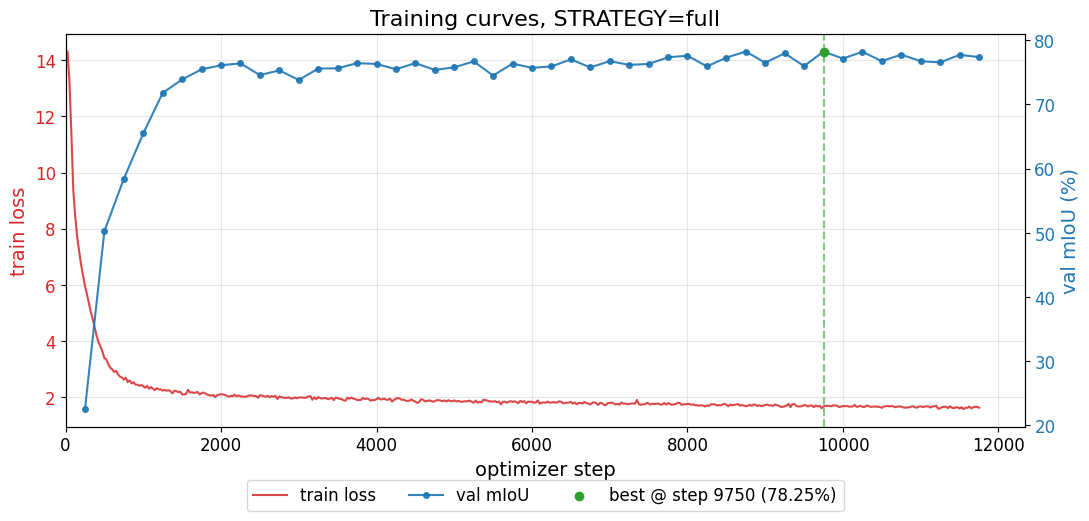

time/elapsed_min,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇███
train/loss,█▇▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/lr,███████████▇▇▇▇▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁
val/best_miou,▁▄▆▆▇▇██████████████████████████████████
val/miou,▁▄▆▆▇▇████▇█████████████████████████████
val/no_improve,▁▁▁▁▁▁▁▁▂▂▃▄▅▁▂▃▄▅▁▂▃▄▁▂▂▃▄▁▂▂▁▂▂▄▅▅▆▇▇█
final/common/bicycle,77.85301
final/common/building,93.64358
final/common/bus,84.65512
final/common/car,94.30218
final/common/fence,65.79546


In [ ]:
import matplotlib.pyplot as plt

if not (train_loss_history or val_miou_history):
    print('no history to plot (no completed log/val intervals yet)')
else:
    # Font sizes — bump them all proportionally for readability in slides/print
    FS_TITLE  = 16
    FS_AXIS   = 14
    FS_TICK   = 12
    FS_LEGEND = 12
    FS_PHASE  = 12   # phase boundary annotations

    fig, ax_loss = plt.subplots(figsize=(11, 5))

    # 1. Adapt data and limits based on the current STRATEGY
    if STRATEGY == "phased":
        cut_step = 16250
        train_data = [(s, l) for s, l in train_loss_history if s <= cut_step]
        val_data = [(s, m) for s, m in val_miou_history if s <= cut_step]
        x_limit = 16500
    else:
        # Use all data for other strategies
        train_data = train_loss_history
        val_data = val_miou_history
        x_limit = None # Let matplotlib decide the limit, or use TOTAL_STEPS

    # Plot Train Loss
    if train_data:
        steps_l, losses = zip(*train_data)
        ax_loss.plot(steps_l, losses, color='tab:red', alpha=0.85, label='train loss')
        ax_loss.set_xlabel('optimizer step', fontsize=FS_AXIS)
        ax_loss.set_ylabel('train loss', color='tab:red', fontsize=FS_AXIS)
        ax_loss.tick_params(axis='x', labelsize=FS_TICK)
        ax_loss.tick_params(axis='y', labelcolor='tab:red', labelsize=FS_TICK)
        ax_loss.grid(True, alpha=0.3)

    # 2. Set the X-axis limit conditionally
    if STRATEGY == "phased":
        ax_loss.set_xlim(0, x_limit)
    else:
        ax_loss.set_xlim(left=0)

    # --- phased only: vertical dashed gray lines at phase transitions -------
    if STRATEGY == "phased":
        cum = 0.0
        for i, frac in enumerate(PHASE_FRACTIONS[:-1]):
            cum += frac
            boundary = int(round(TOTAL_STEPS * cum))
            # Draw the phase line only if it falls within the visual limit
            if boundary <= x_limit:
                ax_loss.axvline(boundary, color='gray', linestyle='--', alpha=0.5, linewidth=1, zorder=1)
                ax_loss.text(boundary, ax_loss.get_ylim()[1], f'  P{i + 2}',
                             color='gray', fontsize=FS_PHASE, va='top', ha='left', alpha=0.8)

    # Plot Val mIoU
    if val_data:
        steps_v, mious = zip(*val_data)
        ax_miou = ax_loss.twinx()
        ax_miou.plot(steps_v, [m * 100 for m in mious],
                     color='tab:blue', marker='o', markersize=4, alpha=0.9,
                     label='val mIoU')
        ax_miou.set_ylabel('val mIoU (%)', color='tab:blue', fontsize=FS_AXIS)
        ax_miou.tick_params(axis='y', labelcolor='tab:blue', labelsize=FS_TICK)

        # Recalculate best_step based on the active data
        best_step, best_v = max(val_data, key=lambda x: x[1])
        ax_miou.axvline(best_step, color='tab:green', linestyle='--', alpha=0.6)
        ax_miou.scatter([best_step], [best_v * 100], color='tab:green', zorder=5,
                        label=f'best @ step {best_step} ({best_v*100:.2f}%)')

        handles_loss, labels_loss = ax_loss.get_legend_handles_labels()
        handles_miou, labels_miou = ax_miou.get_legend_handles_labels()
        fig.legend(handles_loss + handles_miou, labels_loss + labels_miou,
           loc='lower center', bbox_to_anchor=(0.5, -0.05),
           ncol=3, fontsize=FS_LEGEND, frameon=True)

    plt.title(f'Training curves, STRATEGY={STRATEGY}', fontsize=FS_TITLE)
    fig.tight_layout()

    plot_path = FINAL_DIR / f'training_curves_{STRATEGY}.png'
    fig.savefig(plot_path, dpi=120, bbox_inches='tight')
    print(f'training curves saved to {plot_path}')

    # Mirror the figure to wandb. Best-effort: if the run was already closed
    # by a previous execution of this cell, just skip the log silently.
    if wandb_run is not None:
        try:
            import wandb as _wandb
            wandb_run.log({'training_curves': _wandb.Image(str(plot_path))})
        except Exception as e:
            print(f'[warn] wandb log skipped (run already finished): {e}')

    plt.show()

# Close the wandb run cleanly so the dashboard reflects completion.
# Best-effort: idempotent, no-op if already finished.
if wandb_run is not None:
    try:
        wandb_run.finish()
    except Exception:
        pass